In [ ]:
import xgboost as xgb
from modelos.utils.metricas import evaluar_regresion
import matplotlib.pyplot as plt
from sklearn.metrics import PredictionErrorDisplay
from sklearn.model_selection import LearningCurveDisplay
import limpieza.limpieza as clean
from modelos.utils.particiones import split_temporal
import numpy as np

In [61]:
min_error = np.inf
for k in range(10):
    df = clean.bajar_df_final(clasificacion=False) 
    target_col = 'frp_mean'
    num = 120 + k*10
    df = df[df[target_col] <= num]
    y = df[target_col]
    X = df.drop(columns=[target_col], errors='ignore')
    X_train_full, X_test, y_train_full, y_test = split_temporal(X, y, date_col='date', test_size=0.2)

    # Instanciación del modelo
    model = xgb.XGBRegressor(
        objective='reg:tweedie',
        tweedie_variance_power=1.5,
        max_depth=2,
        n_estimators=2000,
        learning_rate=0.016991,
        subsample=0.73205,
        colsample_bytree=0.94425,
        min_child_weight=91,
        gamma=3.19715,
        reg_alpha=0.093344,
        reg_lambda=3.80894,
        random_state=42,
        eval_metric='tweedie-nloglik@1.5',
        # early_stopping_rounds=50,
        n_jobs=-1,
    )

    model.fit(
        X_train_full, y_train_full,
        eval_set=[(X_test, y_test)], 
        verbose=False                      
    )

    y_pred_test = model.predict(X_test)
    metricas_test = evaluar_regresion(y_test, y_pred_test, "Test — XGBoost Regressor", en_log=False)
    dic = {'num':num, 'rmse':metricas_test['rmse'], 'r2': metricas_test['r2']} if metricas_test['rmse'] < min_error else dic
    min_error = min(metricas_test['rmse'], min_error)

Dataframe importado correctamente
Dataset ordenado temporalmente y columna 'date' eliminada.

── Métricas Test — XGBoost Regressor ──────────────────────────────
  RMSE (principal): 17.4359
  MAE             : 14.4941
  R²              : 0.1802
Dataframe importado correctamente
Dataset ordenado temporalmente y columna 'date' eliminada.

── Métricas Test — XGBoost Regressor ──────────────────────────────
  RMSE (principal): 19.7775
  MAE             : 16.2252
  R²              : 0.1994
Dataframe importado correctamente
Dataset ordenado temporalmente y columna 'date' eliminada.

── Métricas Test — XGBoost Regressor ──────────────────────────────
  RMSE (principal): 21.9752
  MAE             : 17.6789
  R²              : 0.1884
Dataframe importado correctamente
Dataset ordenado temporalmente y columna 'date' eliminada.

── Métricas Test — XGBoost Regressor ──────────────────────────────
  RMSE (principal): 23.5291
  MAE             : 18.9288
  R²              : 0.1667
Dataframe importado 

In [62]:
print('Error mininimo segun frp_mean:', dic)

Error mininimo segun frp_mean: {'num': 120, 'rmse': np.float64(17.435935564357656), 'r2': 0.18018287253535037}


Dataframe importado correctamente
Dataset ordenado temporalmente y columna 'date' eliminada.

── Métricas Test — XGBoost Regressor ──────────────────────────────
  RMSE (principal): 17.4359
  MAE             : 14.4941
  R²              : 0.1802


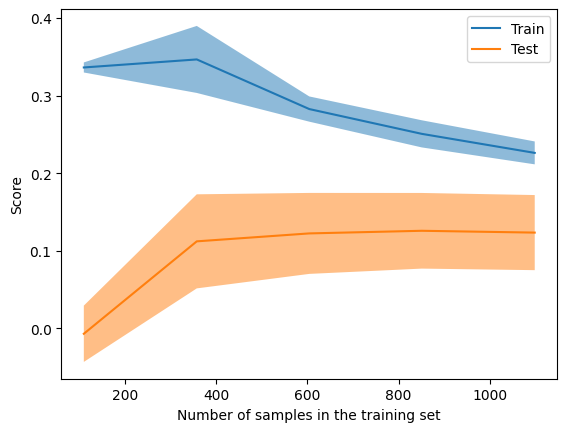

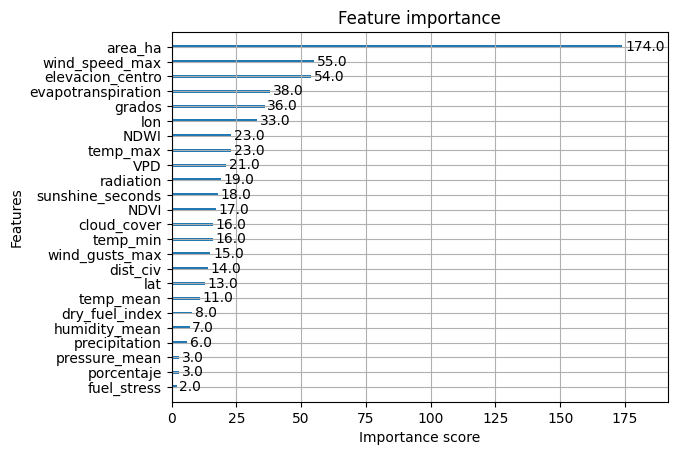

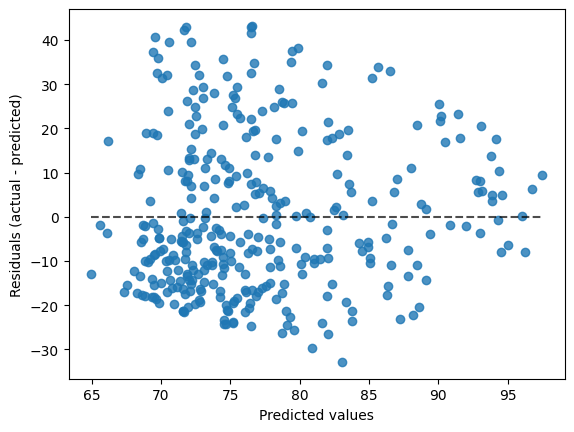

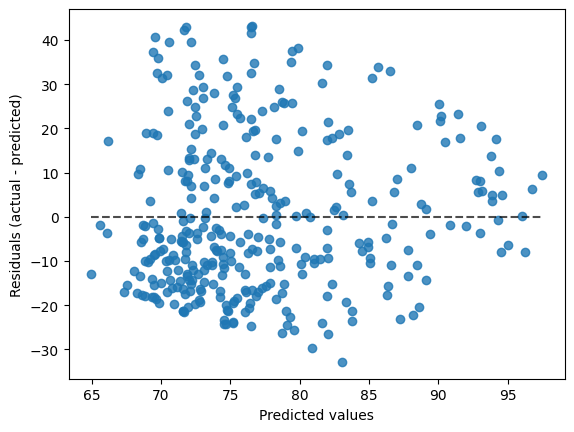

In [63]:
df = clean.bajar_df_final(clasificacion=False) 
target_col = 'frp_mean'
df = df[df[target_col] <= dic['num']]
y = df[target_col]
X = df.drop(columns=[target_col], errors='ignore')
X_train_full, X_test, y_train_full, y_test = split_temporal(X, y, date_col='date', test_size=0.2)

# Instanciación del modelo
model = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    max_depth=2,
    n_estimators=2000,
    learning_rate=0.016991,
    subsample=0.73205,
    colsample_bytree=0.94425,
    min_child_weight=91,
    gamma=3.19715,
    reg_alpha=0.093344,
    reg_lambda=3.80894,
    random_state=42,
    eval_metric='tweedie-nloglik@1.5',
    # early_stopping_rounds=50,
    n_jobs=-1,
)

model.fit(
    X_train_full, y_train_full,
    eval_set=[(X_test, y_test)], 
    verbose=False                      
)

y_pred_test = model.predict(X_test)
metricas_test = evaluar_regresion(y_test, y_pred_test, "Test — XGBoost Regressor", en_log=False)

LearningCurveDisplay.from_estimator(model, X_train_full, y_train_full)
plt.show()

xgb.plot_importance(model)
plt.show()

error_disp = PredictionErrorDisplay.from_estimator(model, X_test, y_test)
error_disp.plot()


In [68]:
df = clean.bajar_df_final(clasificacion=False) 
target_col = 'frp_mean'
df2 = df[df[target_col] <= dic['num']]
df[['area_ha', 'wind_speed_max', 'elevacion_centro']].describe()

Dataframe importado correctamente


,area_ha,wind_speed_max,elevacion_centro
count,2026.000000,2026.000000,2026.000000
mean,534.149526,18.547532,424.696476
std,3335.599916,6.501442,410.182645
min,11.030000,3.700000,-4.045881
25%,14.060000,13.900000,113.903854
50%,28.120000,17.800000,276.835129
75%,115.970000,22.400000,634.575027
max,75446.430000,47.900000,2908.075684


In [69]:
df2[['area_ha', 'wind_speed_max', 'elevacion_centro']].describe()

,area_ha,wind_speed_max,elevacion_centro
count,1718.000000,1718.000000,1718.000000
mean,398.793056,18.301979,412.157921
std,2760.997790,6.389530,406.130623
min,11.030000,3.700000,-4.045881
25%,14.060000,13.800000,108.324396
50%,14.060000,17.600000,258.837097
75%,48.887500,22.100000,615.122238
max,75446.430000,47.900000,2908.075684
